## Carregando os modelos

In [17]:
import joblib
import pandas as pd
import os
pd.set_option('display.max_columns', None)


output_dir = 'data'

rf_wo_smote_todos_anos = joblib.load(os.path.join(output_dir, 'rf_wo_smote_todos_anos.joblib'))
rf_wo_smote_ultimo_ano = joblib.load(os.path.join(output_dir, 'rf_wo_smote_sem_ultimo_ano.joblib'))

df_teste = pd.read_parquet(os.path.join(output_dir, 'df_teste.parquet')).drop("NU_ANO", axis = 1)
df_treino = pd.read_parquet(os.path.join(output_dir, 'df_treino.parquet')).drop("NU_ANO", axis = 1)

X_teste = pd.read_parquet(os.path.join(output_dir, 'X_teste.parquet')).drop("NU_ANO", axis = 1)
X_treino = pd.read_parquet(os.path.join(output_dir, 'X_treino.parquet')).drop("NU_ANO", axis = 1)

y_teste = pd.read_parquet(os.path.join(output_dir, 'y_teste.parquet'))['target'] 
y_treino = pd.read_parquet(os.path.join(output_dir, 'y_treino.parquet'))['target']

# Avaliação de Equidade e Viés
Vamos avaliar diferentes métricas usando como atributo de análise **Raça**, pois

* Dado que a pessoa pertence à classe de óbito, gostaríamos que o modelo tenha a mesma chance de prever corretamente, independentemente da raça.

In [18]:
import numpy as np
import pandas as pd

codigo_raca = {1: "Branca", 2: "Preta", 4: "Parda"}

# one-hot → single column with numeric codes
raca_cols   = ['CS_RACA_1', 'CS_RACA_2', 'CS_RACA_4']
sens_test   = df_teste[raca_cols] @ np.array([1, 2, 4])
sens_train  = df_treino[raca_cols] @ np.array([1, 2, 4])

In [19]:
from fairlearn.metrics import (
    MetricFrame,
    true_positive_rate, false_positive_rate, selection_rate,
    demographic_parity_difference, equalized_odds_difference
)
from sklearn.metrics import accuracy_score, balanced_accuracy_score

def evaluate(model, X, y, sens, thresh=0.5):
    proba  = model.predict_proba(X)[:, 1]
    y_pred = (proba >= thresh).astype(int)

    # group-wise and overall metrics in one object
    mf = MetricFrame(
        metrics={
            'accuracy'        : accuracy_score,
            'balanced_acc'    : balanced_accuracy_score,
            'TPR'             : true_positive_rate,
            'FPR'             : false_positive_rate,
            'selection_rate'  : selection_rate
        },
        y_true=y,
        y_pred=y_pred,
        sensitive_features=sens
    )
    # high-level fairness gaps
    eo_diff  = equalized_odds_difference( y, y_pred, sensitive_features=sens)

    print("\n=== OVERALL ===")
    print(mf.overall)

    print("\n=== POR RAÇA ===")
    print(mf.by_group.rename(index=codigo_raca))

    print(f"Equalized-Odds diff     : {eo_diff:.4f}")
    return mf, eo_diff


_ , eo0 = evaluate(rf_wo_smote_todos_anos, X_teste, y_teste, sens_test)


=== OVERALL ===
accuracy          0.798333
balanced_acc      0.664496
TPR               0.497596
FPR               0.168605
selection_rate    0.201190
dtype: float64

=== POR RAÇA ===
                     accuracy  balanced_acc       TPR       FPR  \
sensitive_feature_0                                               
Branca               0.788030      0.676792  0.539823  0.186239   
Preta                0.797806      0.622883  0.410714  0.164948   
Parda                0.803730      0.668732  0.497976  0.160511   

                     selection_rate  
sensitive_feature_0                  
Branca                     0.219451  
Preta                      0.186520  
Parda                      0.195846  
Equalized-Odds diff     : 0.1291


# Aplicando reweighting para melhorar fairness

In [20]:
import pandas as pd
import numpy as np
from aif360.datasets import BinaryLabelDataset

# criando col unica para raca
sens_train_numeric = df_treino[raca_cols].values @ np.array([1, 2, 4])
df_treino['RACA'] = sens_train_numeric


features_cols = [col for col in df_treino.columns if col not in ['SITUACAO_AGRUPADA', 'RACA']]

df_train_aif = df_treino[features_cols].copy()
df_train_aif['SITUACAO_AGRUPADA'] = df_treino['SITUACAO_AGRUPADA']
df_train_aif['RACA'] = df_treino['RACA']

train_bld = BinaryLabelDataset(
    df=df_train_aif,
    label_names=['SITUACAO_AGRUPADA'],
    protected_attribute_names=['RACA'],
    favorable_label=1,
    unfavorable_label=0
)

from aif360.algorithms.preprocessing import Reweighing

rw = Reweighing(unprivileged_groups=[{'RACA': 2}, {'RACA': 4}], privileged_groups=[{'RACA': 1}]) # 2 (preta) como unprivileged (pois TPR estava baixo), 1 (branca) como privileged
rw.fit(train_bld)
train_rw = rw.transform(train_bld)

sample_weights = train_rw.instance_weights

X_train = df_train_aif[features_cols].values
y_train = df_train_aif['SITUACAO_AGRUPADA'].values

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline com scaler e random forest (sem SMOTE)
rf_fair = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(
        class_weight=None,
        max_depth=10,
        min_samples_split=10,
        n_estimators=10,
        random_state=42
    ))
])

rf_fair.fit(X_treino, y_treino, modelo__sample_weight= sample_weights)

Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo',
                 RandomForestClassifier(max_depth=10, min_samples_split=10,
                                        n_estimators=10, random_state=42))])

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, classification_report
)

def plot_confusion_matrix_normalizada_com_metricas(y_true, y_probs, threshold=0.5):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    # Normalização por linha (classe real)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Exibição da matriz
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["Classe 0", "Classe 1"])
    plt.figure(figsize=(6, 6))
    disp_norm.plot(cmap="Blues", values_format=".2f")
    plt.title(f'Matriz de Confusão Normalizada (Threshold = {threshold})')
    plt.grid(False)
    plt.show()
    
    # Tabela com métricas
    print(classification_report(y_true, y_pred, digits=4))

<Figure size 600x600 with 0 Axes>

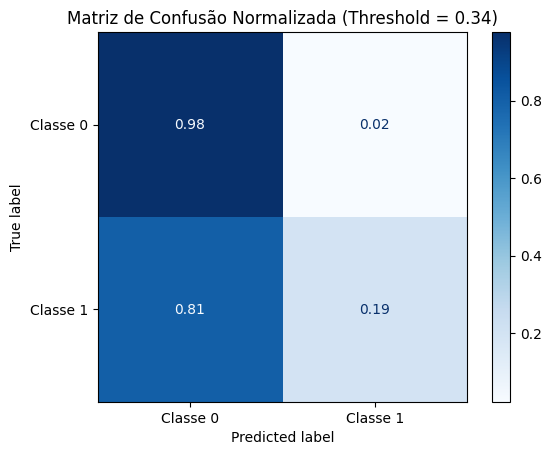

              precision    recall  f1-score   support

           0     0.9169    0.9767    0.9459      3784
           1     0.4793    0.1947    0.2769       416

    accuracy                         0.8993      4200
   macro avg     0.6981    0.5857    0.6114      4200
weighted avg     0.8736    0.8993    0.8796      4200



In [23]:
probs_teste = rf_fair.predict_proba(X_teste)[:, 1]

plot_confusion_matrix_normalizada_com_metricas(y_teste, probs_teste, threshold=0.34)

In [24]:
print("\nFairness-aware model:")
evaluate(rf_fair, X_teste, y_teste, sens_test, thresh=0.34)


Fairness-aware model:

=== OVERALL ===
accuracy          0.899286
balanced_acc      0.585728
TPR               0.194712
FPR               0.023256
selection_rate    0.040238
dtype: float64

=== POR RAÇA ===
                     accuracy  balanced_acc       TPR       FPR  \
sensitive_feature_0                                               
Branca               0.899418      0.599448  0.230088  0.031193   
Preta                0.904389      0.560260  0.142857  0.022337   
Parda                0.897838      0.585435  0.190283  0.019413   

                     selection_rate  
sensitive_feature_0                  
Branca                     0.049875  
Preta                      0.032915  
Parda                      0.037304  
Equalized-Odds diff     : 0.0872


(<fairlearn.metrics._metric_frame.MetricFrame at 0x13f0d8edf40>,
 0.08723135271807839)